<a href="https://colab.research.google.com/github/zaragucci996/Fitness-Data-Analysis-/blob/main/Equipment_failure.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

from google.colab import files

uploaded = files.upload()

Saving dataset_06_equipment_failure_warning.csv to dataset_06_equipment_failure_warning.csv


In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:

import pandas as pd

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

df.head()

,temperature,vibration,pressure,runtime_hours,maintenance_gap_days,power_draw,target
0,62.10,1.01,86.17,1.00,16,63.81,0
1,78.78,0.10,95.62,17.13,54,298.61,1
2,76.70,5.28,130.00,19.59,29,245.18,1
3,88.05,4.22,93.83,1.04,52,328.36,1
4,71.58,6.59,103.01,19.12,43,345.48,0


In [6]:

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

Dataset Shape:
(1000, 7)

Column Names:
Index(['temperature', 'vibration', 'pressure', 'runtime_hours',
       'maintenance_gap_days', 'power_draw', 'target'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   temperature           1000 non-null   float64
 1   vibration             1000 non-null   float64
 2   pressure              1000 non-null   float64
 3   runtime_hours         1000 non-null   float64
 4   maintenance_gap_days  1000 non-null   int64  
 5   power_draw            1000 non-null   float64
 6   target                1000 non-null   int64  
dtypes: float64(5), int64(2)
memory usage: 54.8 KB


In [7]:
print(df.isnull().sum())

temperature             0
vibration               0
pressure                0
runtime_hours           0
maintenance_gap_days    0
power_draw              0
target                  0
dtype: int64


In [8]:

X = df.drop("target", axis=1)
y = df["target"]

print("Input Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Input Features:
   temperature  vibration  pressure  runtime_hours  maintenance_gap_days  \
0        62.10       1.01     86.17           1.00                    16   
1        78.78       0.10     95.62          17.13                    54   
2        76.70       5.28    130.00          19.59                    29   
3        88.05       4.22     93.83           1.04                    52   
4        71.58       6.59    103.01          19.12                    43   

   power_draw  
0       63.81  
1      298.61  
2      245.18  
3      328.36  
4      345.48  

Target:
0    0
1    1
2    1
3    1
4    0
Name: target, dtype: int64


In [9]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 6)
Testing data: (200, 6)


In [10]:

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [11]:

y_pred = model.predict(X_test)

print("Predicted values:")
print(y_pred)

Predicted values:
[1 0 1 1 1 1 1 1 0 1 0 0 0 1 1 0 0 1 0 0 0 0 0 1 1 0 1 1 0 0 0 0 0 1 0 0 0
 1 0 1 0 0 0 1 0 1 1 1 1 0 1 1 1 0 1 1 1 1 1 1 1 0 0 1 1 0 0 1 1 0 1 1 0 0
 0 0 1 1 1 0 1 0 0 0 1 1 0 1 1 0 0 1 0 1 0 1 1 0 1 0 1 1 1 1 0 1 1 1 1 0 1
 0 0 1 0 1 1 0 1 0 0 1 0 1 1 1 1 1 1 0 0 1 1 0 1 0 0 0 0 1 0 0 1 0 0 0 1 1
 0 0 1 0 1 1 1 1 1 1 0 0 0 1 1 1 1 0 1 1 0 0 0 0 1 0 1 0 1 1 0 0 0 0 1 1 0
 0 1 0 0 1 1 1 1 1 0 1 0 0 1 0]


In [12]:

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.74      0.73        92
           1       0.77      0.76      0.77       108

    accuracy                           0.75       200
   macro avg       0.75      0.75      0.75       200
weighted avg       0.75      0.75      0.75       200



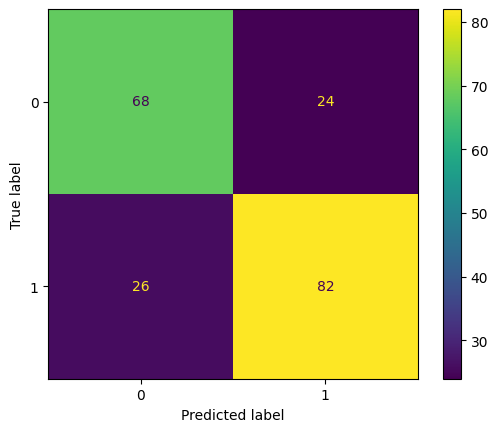

In [13]:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

display = ConfusionMatrixDisplay(confusion_matrix=cm)

display.plot()

plt.show()

In [14]:

result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

result.head(20)

,Actual,Predicted
0,0,1
1,0,0
2,1,1
3,1,1
4,1,1
5,1,1
6,1,1
7,1,1
8,1,0
9,1,1


In [15]:

new_machine = [[
    70,    # temperature
    5,     # vibration
    100,   # pressure
    500,   # runtime_hours
    30,    # maintenance_gap_days
    200    # power_draw
]]

prediction = model.predict(new_machine)

print("Prediction:", prediction[0])

Prediction: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
